#### IMPORTING DATA

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load Employee dataset
data = pd.read_csv('Employee.csv')
data.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [2]:
data.LeaveOrNot.value_counts(normalize=True)

LeaveOrNot
0    0.656136
1    0.343864
Name: proportion, dtype: float64

In [3]:
# Capitalize all Column Names
data.columns = data.columns.str.upper()

In [4]:
data.describe()

,JOININGYEAR,PAYMENTTIER,AGE,EXPERIENCEINCURRENTDOMAIN,LEAVEORNOT
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   EDUCATION                  4653 non-null   str  
 1   JOININGYEAR                4653 non-null   int64
 2   CITY                       4653 non-null   str  
 3   PAYMENTTIER                4653 non-null   int64
 4   AGE                        4653 non-null   int64
 5   GENDER                     4653 non-null   str  
 6   EVERBENCHED                4653 non-null   str  
 7   EXPERIENCEINCURRENTDOMAIN  4653 non-null   int64
 8   LEAVEORNOT                 4653 non-null   int64
dtypes: int64(5), str(4)
memory usage: 327.3 KB


#### DATA CLEANING

In [6]:
# CHECK AND DROP DUPLICATES
print('DF_before:', data.shape)
print('Duplicates:', data.duplicated().sum())
data = data.drop_duplicates()
data = data.reset_index(drop=True)
print('\nDF_after dropping the duplicates:', data.shape)
data.info()
data.head()

DF_before: (4653, 9)
Duplicates: 1889

DF_after dropping the duplicates: (2764, 9)
<class 'pandas.DataFrame'>
RangeIndex: 2764 entries, 0 to 2763
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   EDUCATION                  2764 non-null   str  
 1   JOININGYEAR                2764 non-null   int64
 2   CITY                       2764 non-null   str  
 3   PAYMENTTIER                2764 non-null   int64
 4   AGE                        2764 non-null   int64
 5   GENDER                     2764 non-null   str  
 6   EVERBENCHED                2764 non-null   str  
 7   EXPERIENCEINCURRENTDOMAIN  2764 non-null   int64
 8   LEAVEORNOT                 2764 non-null   int64
dtypes: int64(5), str(4)
memory usage: 194.5 KB


,EDUCATION,JOININGYEAR,CITY,PAYMENTTIER,AGE,GENDER,EVERBENCHED,EXPERIENCEINCURRENTDOMAIN,LEAVEORNOT
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [7]:
# NULL VALUE CHECK
print('Null values per column:')
print(data.isnull().sum())

Null values per column:
EDUCATION                    0
JOININGYEAR                  0
CITY                         0
PAYMENTTIER                  0
AGE                          0
GENDER                       0
EVERBENCHED                  0
EXPERIENCEINCURRENTDOMAIN    0
LEAVEORNOT                   0
dtype: int64


In [8]:
# TRANSFORM TARGET COLUMN: 1 -> 'Leave', 0 -> 'Stay'
data['LEAVEORNOT'] = data['LEAVEORNOT'].map({1: 'Leave', 0: 'Stay'})
print(data['LEAVEORNOT'].value_counts())
data.head()

LEAVEORNOT
Stay     1676
Leave    1088
Name: count, dtype: int64


,EDUCATION,JOININGYEAR,CITY,PAYMENTTIER,AGE,GENDER,EVERBENCHED,EXPERIENCEINCURRENTDOMAIN,LEAVEORNOT
0,Bachelors,2017,Bangalore,3,34,Male,No,0,Stay
1,Bachelors,2013,Pune,1,28,Female,No,3,Leave
2,Bachelors,2014,New Delhi,3,38,Female,No,2,Stay
3,Masters,2016,Bangalore,3,27,Male,No,5,Leave
4,Masters,2017,Pune,3,24,Male,Yes,2,Leave


In [9]:
print(data.isnull().sum())
print()
print(data.dtypes)

EDUCATION                    0
JOININGYEAR                  0
CITY                         0
PAYMENTTIER                  0
AGE                          0
GENDER                       0
EVERBENCHED                  0
EXPERIENCEINCURRENTDOMAIN    0
LEAVEORNOT                   0
dtype: int64

EDUCATION                      str
JOININGYEAR                  int64
CITY                           str
PAYMENTTIER                  int64
AGE                          int64
GENDER                         str
EVERBENCHED                    str
EXPERIENCEINCURRENTDOMAIN    int64
LEAVEORNOT                     str
dtype: object


In [10]:
data.describe()

,JOININGYEAR,PAYMENTTIER,AGE,EXPERIENCEINCURRENTDOMAIN
count,2764.000000,2764.000000,2764.000000,2764.000000
mean,2015.090449,2.636035,30.952967,2.644356
std,1.885943,0.624001,5.108872,1.610610
min,2012.000000,1.000000,22.000000,0.000000
25%,2013.000000,2.000000,27.000000,1.000000
50%,2015.000000,3.000000,30.000000,2.000000
75%,2017.000000,3.000000,35.000000,4.000000
max,2018.000000,3.000000,41.000000,7.000000


#### SELECTING CATEGORICAL AND NUMERICAL FOR PROCESSING

In [11]:
X = data.drop(columns=['LEAVEORNOT'])
y = data['LEAVEORNOT']

X.select_dtypes(include=[object]).head()

,EDUCATION,CITY,GENDER,EVERBENCHED
0,Bachelors,Bangalore,Male,No
1,Bachelors,Pune,Female,No
2,Bachelors,New Delhi,Female,No
3,Masters,Bangalore,Male,No
4,Masters,Pune,Male,Yes


In [12]:
# CATEGORICAL: object dtype columns only
categorical_features = list(X.select_dtypes(include=[object]).columns)
print('\n', 'Categorical Features', '\n', categorical_features, '\n')


 Categorical Features 
 ['EDUCATION', 'CITY', 'GENDER', 'EVERBENCHED'] 



In [13]:
# NUMERICAL: all int64 columns including PAYMENTTIER
# PaymentTier is kept as numerical — consistent with class notebook pipeline
numerical_features = list(X.select_dtypes(include=[np.int64]).columns)
print('\n', 'Numerical Features', '\n', numerical_features, '\n')


 Numerical Features 
 ['JOININGYEAR', 'PAYMENTTIER', 'AGE', 'EXPERIENCEINCURRENTDOMAIN'] 



#### EXPLORATORY DATA ANALYSIS

##### UNIVARIATE

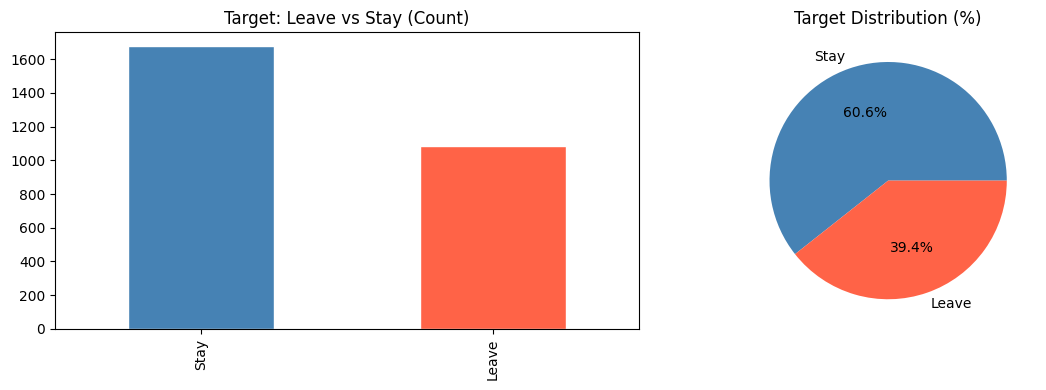

In [14]:
# TARGET DISTRIBUTION
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data['LEAVEORNOT'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Target: Leave vs Stay (Count)')
axes[0].set_xlabel('')
data['LEAVEORNOT'].value_counts(normalize=True).plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Target Distribution (%)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [15]:
## INSIGHT
# Class imbalance: ~61% Stay vs ~39% Leave.
# Recall on Leave class is the right evaluation metric — missing a leaver
# costs more than a false alarm.

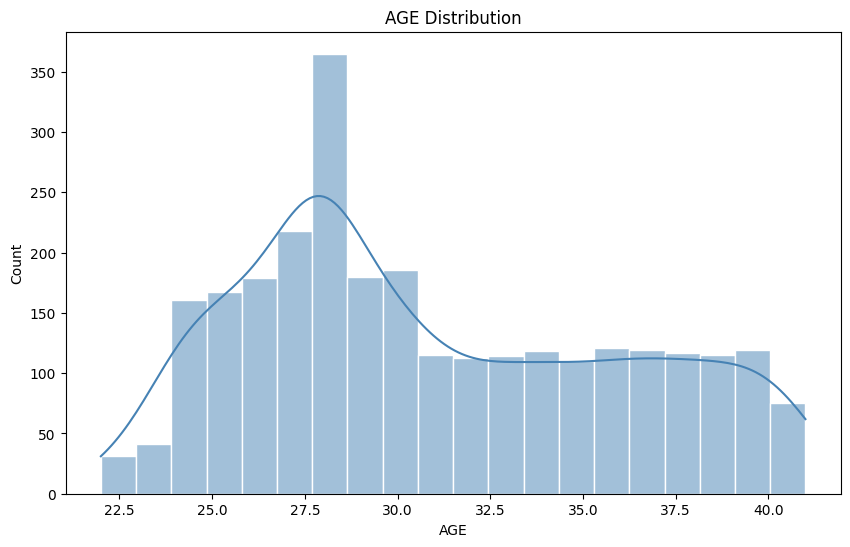

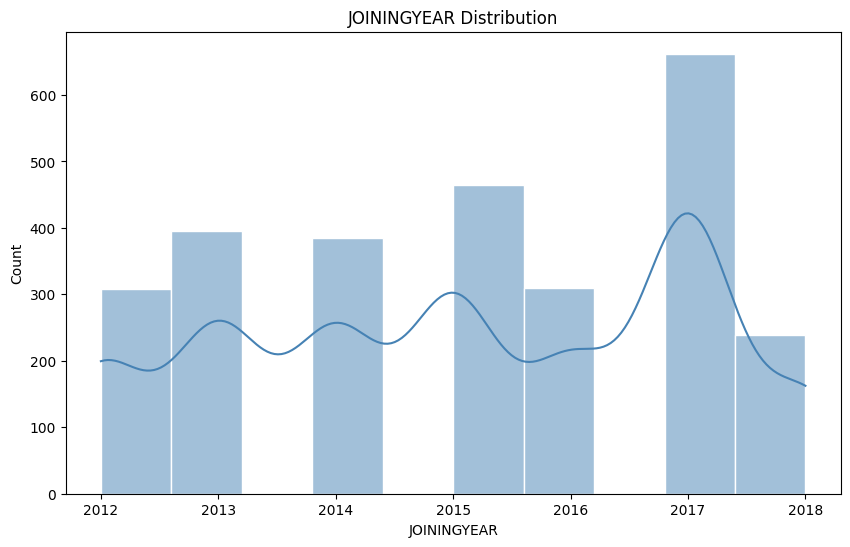

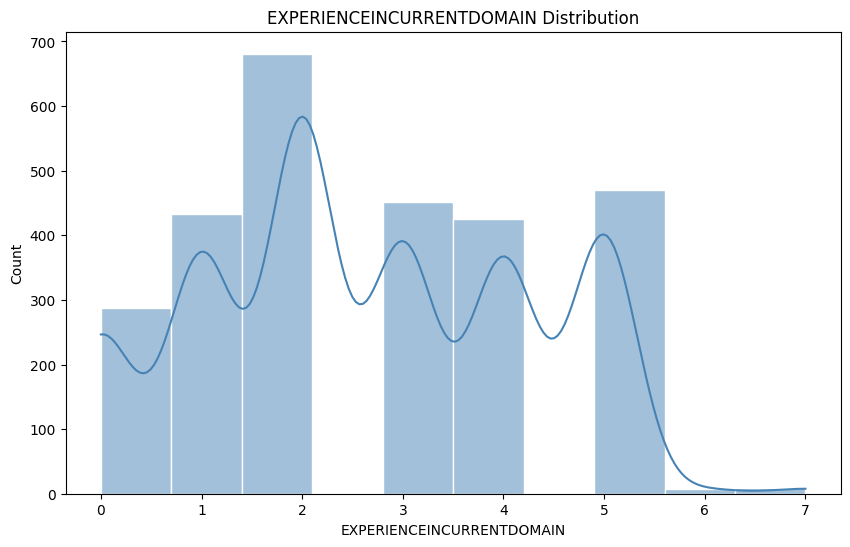

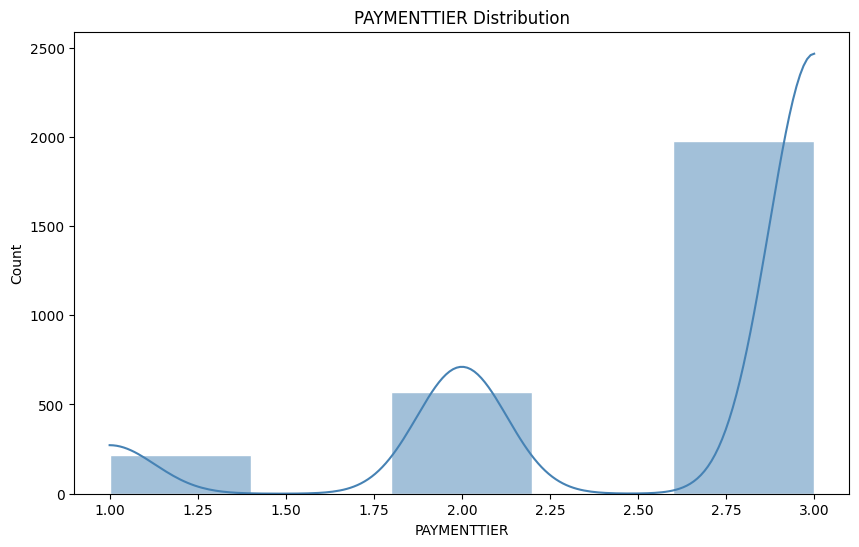

In [16]:
# UNIVARIATE: NUMERICAL FEATURES
def create_histogram_uni(df, var, bins=15, kde=True, title=None, xlabel=None, ylabel='Count', figsize=(10, 6)):
    plt.figure(figsize=figsize)
    sns.histplot(data=df, x=var, bins=bins, kde=kde, color='steelblue', edgecolor='white')
    plt.title(title or f'{var} Distribution')
    plt.xlabel(xlabel or var)
    plt.ylabel(ylabel)
    plt.show()

create_histogram_uni(data, 'AGE', bins=20)
create_histogram_uni(data, 'JOININGYEAR', bins=10)
create_histogram_uni(data, 'EXPERIENCEINCURRENTDOMAIN', bins=10)
create_histogram_uni(data, 'PAYMENTTIER', bins=5)

In [17]:
## INSIGHT
# AGE: right-skewed, majority between 22-35, young workforce.
# JOININGYEAR: peaks at 2017-2018, recent hires dominate.
# EXPERIENCEINCURRENTDOMAIN: low (0-4 years for most), early-career profile.
# PAYMENTTIER: Tier 3 dominates (~70%), non-uniform but treated as numeric per pipeline design.

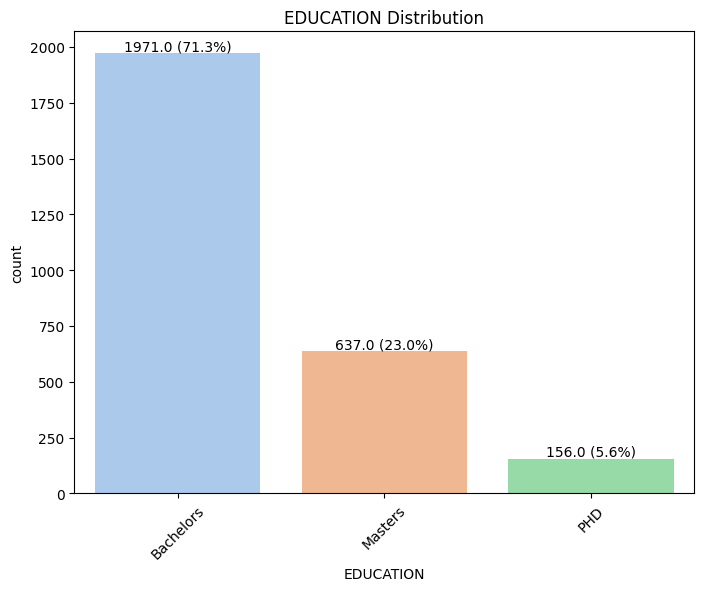

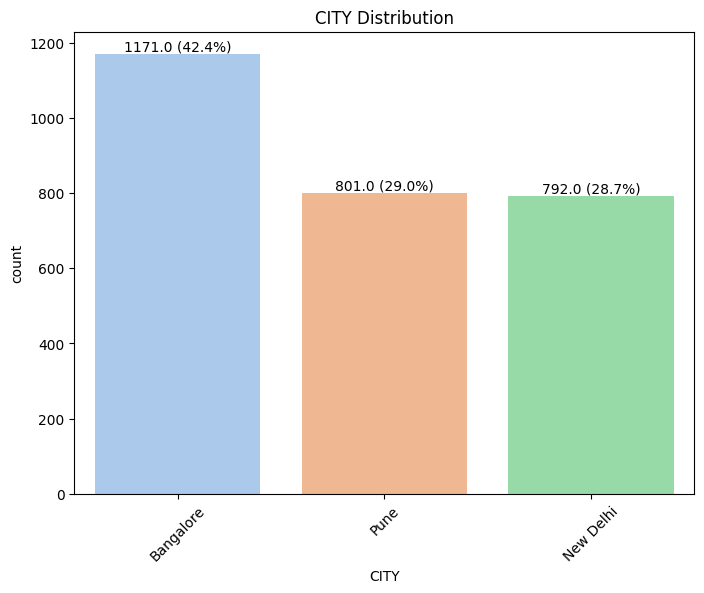

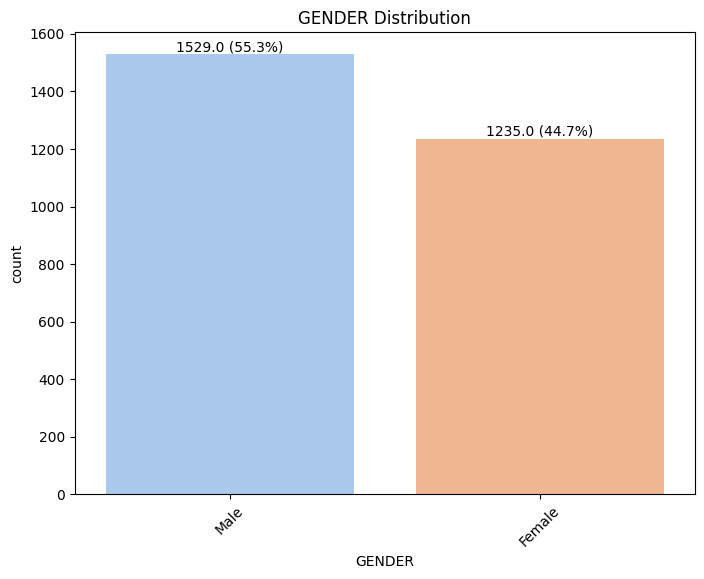

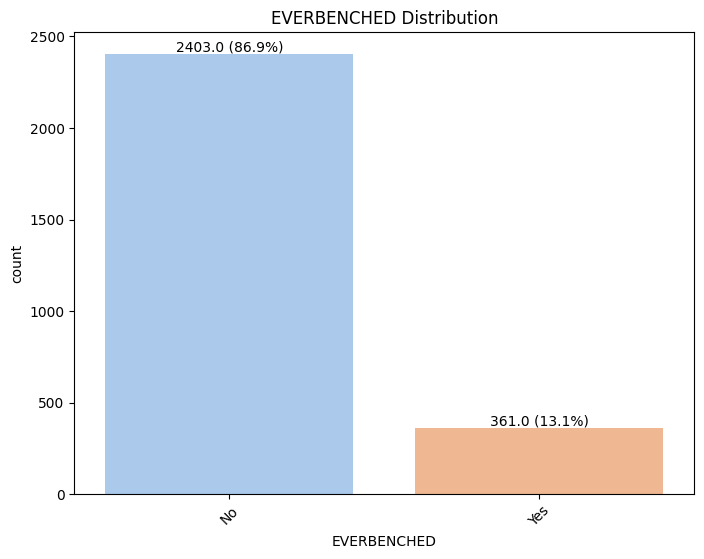

In [18]:
# UNIVARIATE: CATEGORICAL FEATURES
def create_bar_uni(df, var, title=None, palette='pastel', figsize=(8, 6)):
    category_counts = df[var].value_counts()
    total_count = len(df)
    category_percentages = (category_counts / total_count) * 100
    plt.figure(figsize=figsize)
    ax = sns.countplot(data=df, x=var, order=category_counts.index, palette=palette)
    plt.title(title or f'{var} Distribution')
    plt.xticks(rotation=45)
    for p, pct in zip(ax.patches, category_percentages):
        ax.annotate(f'{p.get_height()} ({pct:.1f}%)',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')
    plt.show()

create_bar_uni(data, 'EDUCATION')
create_bar_uni(data, 'CITY')
create_bar_uni(data, 'GENDER')
create_bar_uni(data, 'EVERBENCHED')

In [19]:
## INSIGHT
# EDUCATION: Bachelors dominate (~78%).
# CITY: Bangalore is the largest group.
# GENDER: Male-majority (~60%).
# EVERBENCHED: ~90% No — benching is the exception, not the norm.

##### BI VARIATE

###### AGE vs LEAVEORNOT

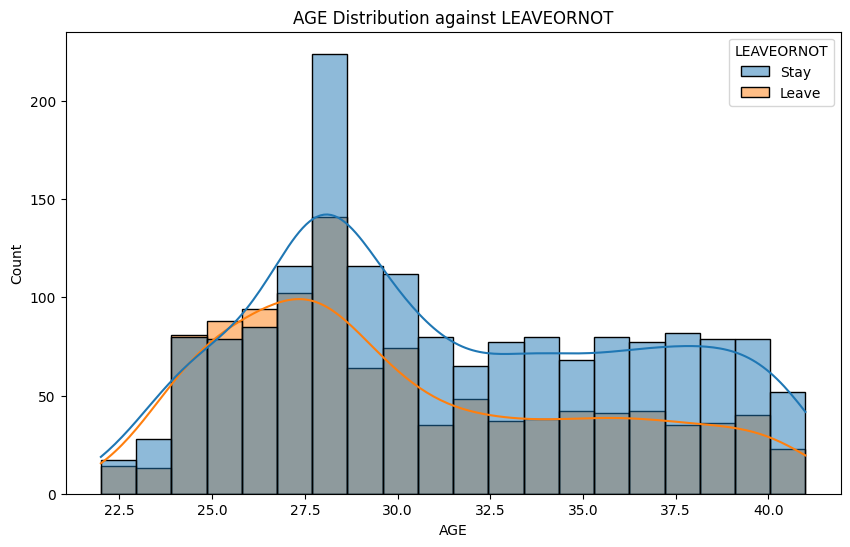

In [20]:
## Python Pandas / Seaborn / Matplotlib Solution
def create_histogram_bi(df, var, hue=None, bins=20, kde=True, title=None, figsize=(10, 6)):
    plt.figure(figsize=figsize)
    sns.histplot(data=df, x=var, hue=hue, bins=bins, kde=kde)
    plt.title(title or f'{var} Distribution against {hue}')
    plt.show()

create_histogram_bi(data, var='AGE', hue='LEAVEORNOT', bins=20)

In [21]:
## INSIGHT
# Younger employees (22-32) show higher Leave counts.
# Age is likely the strongest individual predictor of churn.

###### EXPERIENCEINCURRENTDOMAIN vs LEAVEORNOT

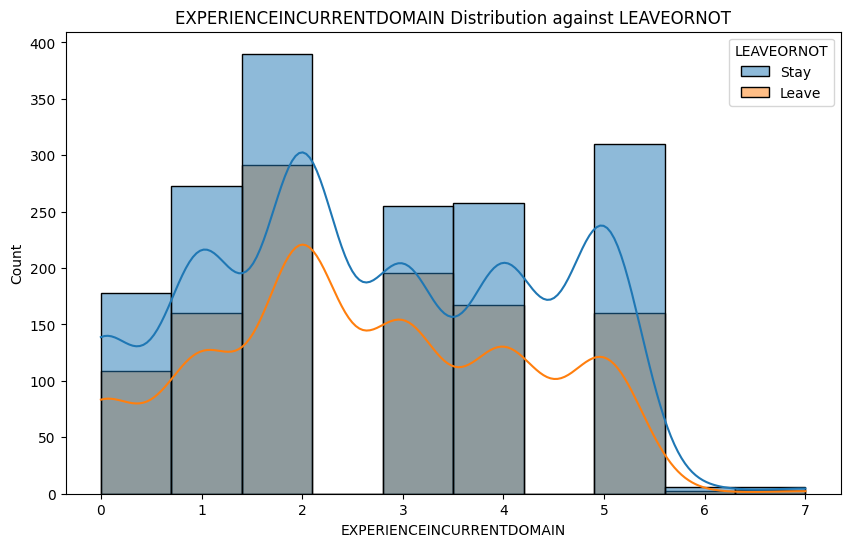

In [22]:
## Python Pandas / Seaborn / Matplotlib Solution
create_histogram_bi(data, var='EXPERIENCEINCURRENTDOMAIN', hue='LEAVEORNOT', bins=10)

In [23]:
## INSIGHT
# Employees with 0-2 years domain experience leave at higher rate.
# Low experience + young age = highest-risk churn profile.

###### EVERBENCHED vs LEAVEORNOT

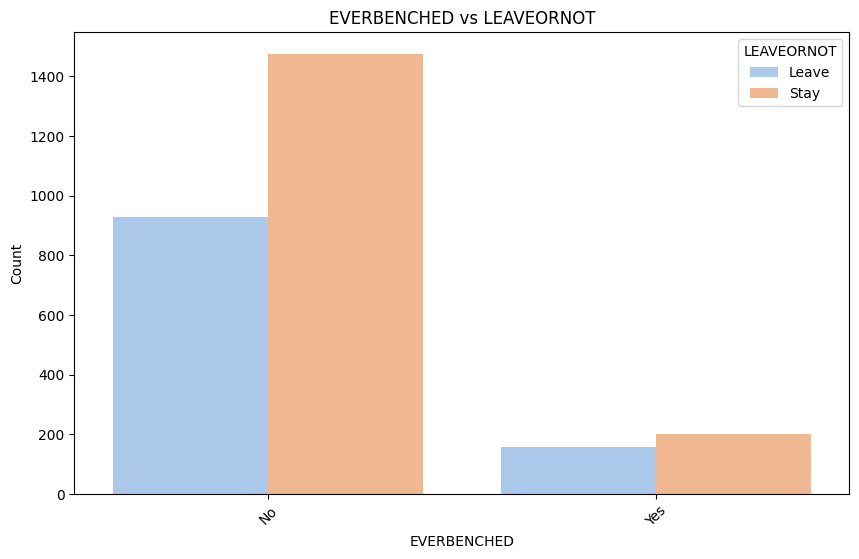

In [24]:
## Python Pandas / Seaborn / Matplotlib Solution
def plot_grouped_percentages(df, group_var, target_var, palette='pastel', figsize=(10, 6), title=None):
    group_counts = df.groupby([group_var, target_var]).size().unstack(fill_value=0)
    combined_df = group_counts.stack().reset_index(name='Count')
    combined_df['Percentage'] = (combined_df['Count'] /
                                  combined_df.groupby(group_var)['Count'].transform('sum')) * 100
    plt.figure(figsize=figsize)
    sns.barplot(data=combined_df, x=group_var, y='Count', hue=target_var, palette=palette)
    plt.title(title or f'{group_var} vs {target_var}')
    plt.xticks(rotation=45)
    plt.legend(title=target_var, loc='upper right')
    plt.show()

plot_grouped_percentages(data, 'EVERBENCHED', 'LEAVEORNOT')

In [25]:
## INSIGHT
# Benched employees have notably higher Leave percentage.
# Being benched signals disengagement — meaningful churn signal.

###### PAYMENTTIER vs LEAVEORNOT

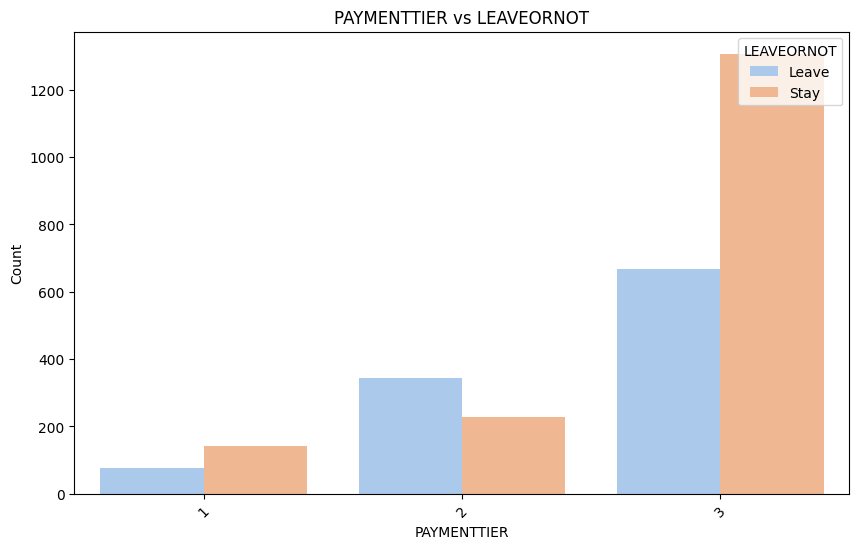

In [26]:
## Python Pandas / Seaborn / Matplotlib Solution
plot_grouped_percentages(data, 'PAYMENTTIER', 'LEAVEORNOT')

In [27]:
## INSIGHT
# Tier 1 employees have highest Leave rate — lower salary drives churn.
# Leave rate decreases as tier increases: Tier 1 > Tier 2 > Tier 3.

###### CITY vs LEAVEORNOT

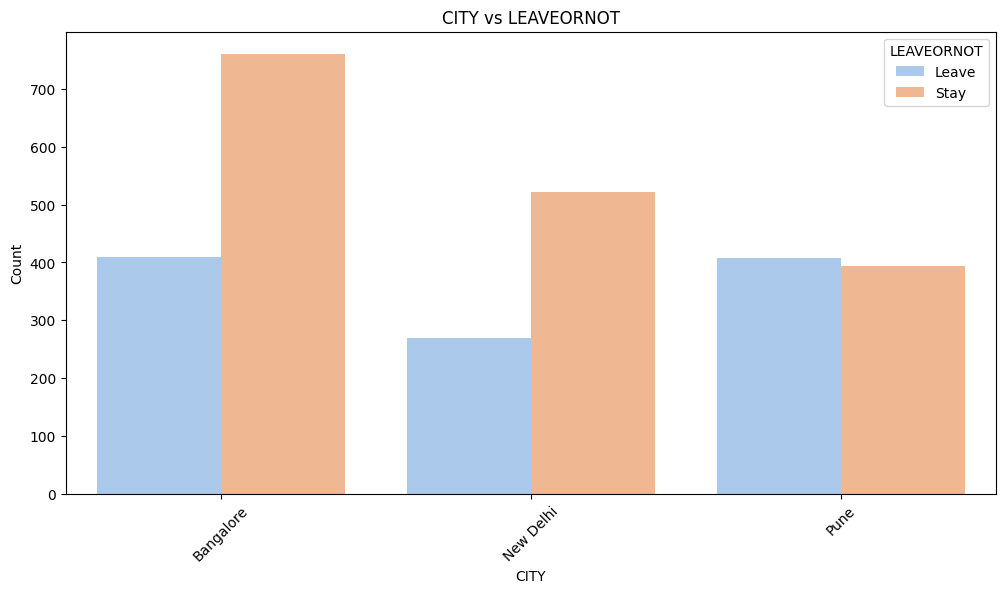

In [28]:
## Python Pandas / Seaborn / Matplotlib Solution
plot_grouped_percentages(data, 'CITY', 'LEAVEORNOT', figsize=(12, 6))

In [29]:
## INSIGHT
# New Delhi shows slightly higher Leave rate vs Bangalore and Pune.

##### MULTI VARIATE

###### AGE + CITY + LEAVEORNOT

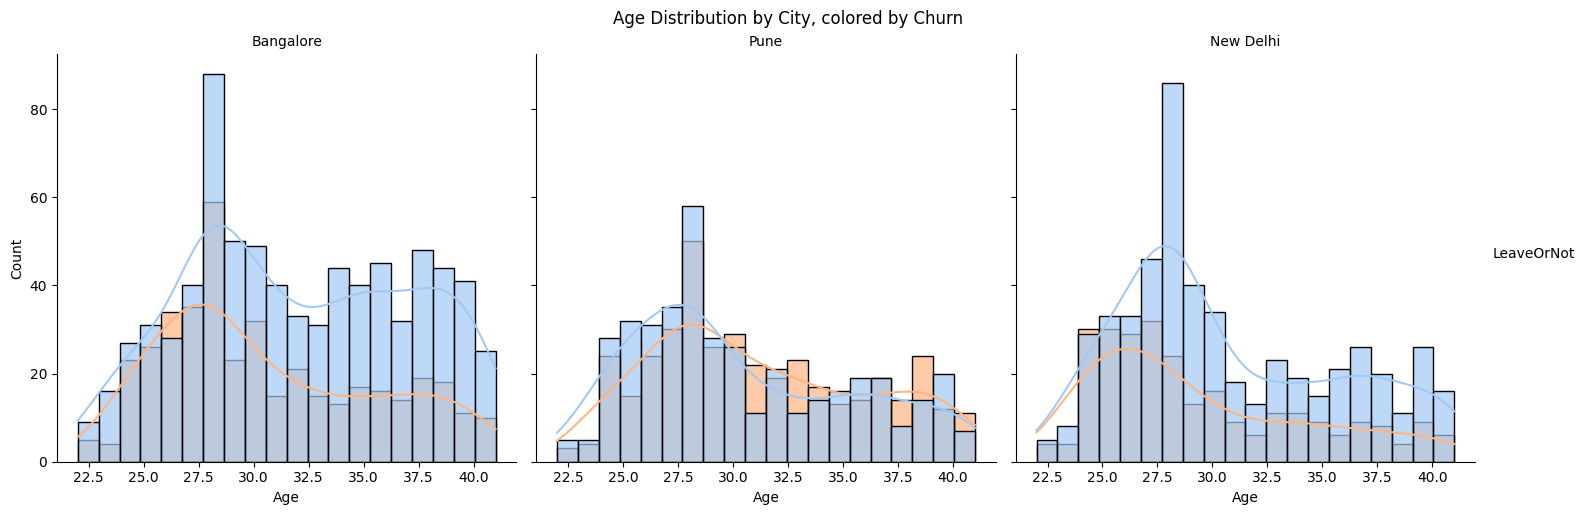

In [30]:
## Python Pandas / Seaborn / Matplotlib Solution
g = sns.FacetGrid(data, col='CITY', height=5)
g.map_dataframe(sns.histplot, x='AGE', bins=20, kde=True,
                hue='LEAVEORNOT', palette='pastel', alpha=0.7)
g.set_titles(col_template='{col_name}')
g.set_axis_labels('Age', 'Count')
g.add_legend(title='LeaveOrNot')
plt.suptitle('Age Distribution by City, colored by Churn', y=1.02)
plt.show()

In [31]:
## INSIGHT
# In all three cities, younger employees dominate the Leave group consistently.
# City alone does not drive churn — Age is the dominant force within each city.

###### EXPERIENCEINCURRENTDOMAIN + EDUCATION + LEAVEORNOT

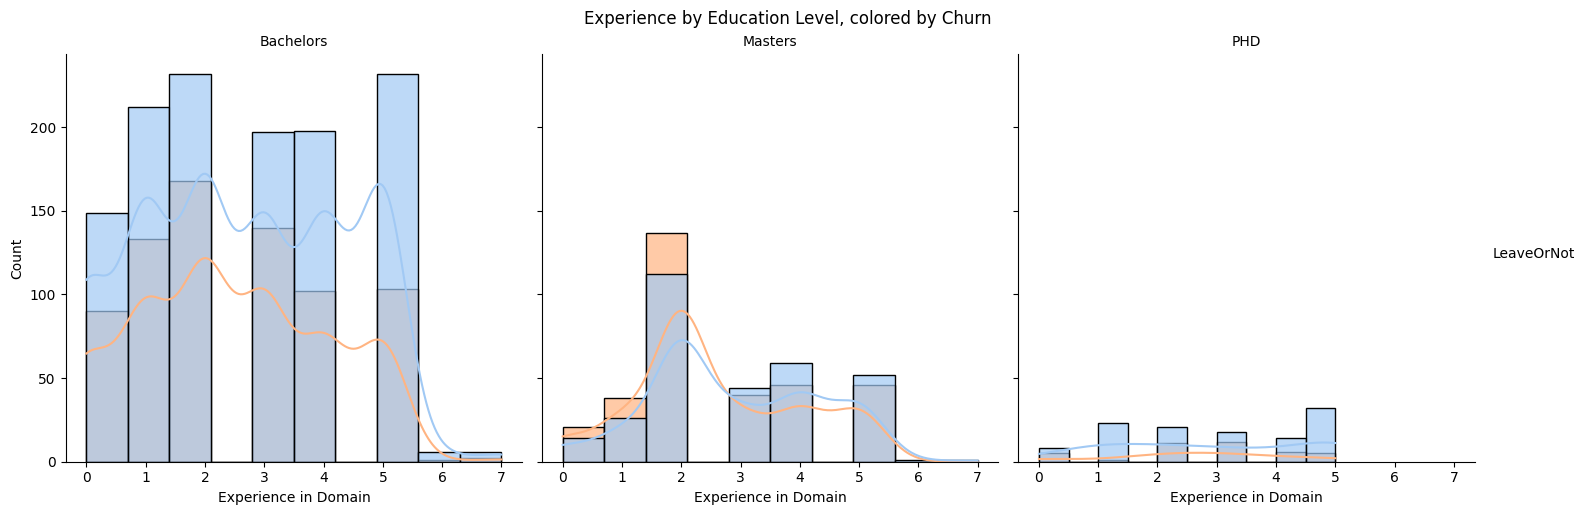

In [32]:
## Python Pandas / Seaborn / Matplotlib Solution
g2 = sns.FacetGrid(data, col='EDUCATION', height=5)
g2.map_dataframe(sns.histplot, x='EXPERIENCEINCURRENTDOMAIN', bins=10, kde=True,
                 hue='LEAVEORNOT', palette='pastel', alpha=0.7)
g2.set_titles(col_template='{col_name}')
g2.set_axis_labels('Experience in Domain', 'Count')
g2.add_legend(title='LeaveOrNot')
plt.suptitle('Experience by Education Level, colored by Churn', y=1.02)
plt.show()

In [33]:
## INSIGHT
# Bachelors with low experience show highest Leave concentration.
# PHD employees show more stability regardless of experience level.

###### AGE + EVERBENCHED + LEAVEORNOT

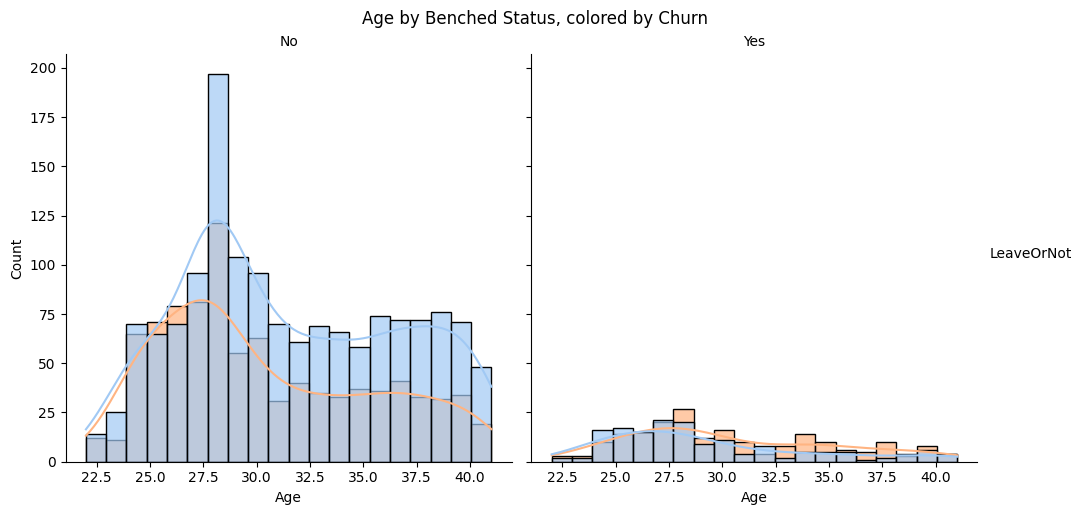

In [34]:
## Python Pandas / Seaborn / Matplotlib Solution
g3 = sns.FacetGrid(data, col='EVERBENCHED', height=5)
g3.map_dataframe(sns.histplot, x='AGE', bins=20, kde=True,
                 hue='LEAVEORNOT', palette='pastel', alpha=0.7)
g3.set_titles(col_template='{col_name}')
g3.set_axis_labels('Age', 'Count')
g3.add_legend(title='LeaveOrNot')
plt.suptitle('Age by Benched Status, colored by Churn', y=1.02)
plt.show()

In [35]:
## INSIGHT
# Benched employees leave at higher rate across all age groups.
# Young + benched = highest Leave risk combination.

#### SPLITTING DATA FOR TRAIN / TEST

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)

In [37]:
print('Train Data', '\n', y_train.value_counts(normalize=True),
      '\n', '\n', 'Test Data', '\n', y_test.value_counts(normalize=True))

Train Data 
 LEAVEORNOT
Stay     0.606513
Leave    0.393487
Name: proportion, dtype: float64 
 
 Test Data 
 LEAVEORNOT
Stay     0.605787
Leave    0.394213
Name: proportion, dtype: float64


#### EXPORTING FEATURE INPUT METADATA

In [38]:
def summarize_cat(data, categorical_features):
    results = []
    for column in data[categorical_features]:
        members = data[column].astype(str).unique().tolist()
        results.append([column, members])
    return pd.DataFrame(results, columns=['Column Name', 'Members'])

summarize_cat(X_train, categorical_features)

,Column Name,Members
0,EDUCATION,"[Bachelors, Masters, PHD]"
1,CITY,"[Bangalore, New Delhi, Pune]"
2,GENDER,"[Female, Male]"
3,EVERBENCHED,"[No, Yes]"


In [39]:
summarize_cat(data, categorical_features).to_dict()

{'Column Name': {0: 'EDUCATION', 1: 'CITY', 2: 'GENDER', 3: 'EVERBENCHED'},
 'Members': {0: ['Bachelors', 'Masters', 'PHD'],
  1: ['Bangalore', 'Pune', 'New Delhi'],
  2: ['Male', 'Female'],
  3: ['No', 'Yes']}}

In [40]:
# EXPORTING FOR STREAMLIT APP
my_feature_dict = {
    'CATEGORICAL': summarize_cat(data, categorical_features).to_dict(),
    'NUMERICAL':   {'Column Name': numerical_features}
}

my_feature_dict.get('NUMERICAL')

{'Column Name': ['JOININGYEAR',
  'PAYMENTTIER',
  'AGE',
  'EXPERIENCEINCURRENTDOMAIN']}

In [41]:
my_feature_dict

{'CATEGORICAL': {'Column Name': {0: 'EDUCATION',
   1: 'CITY',
   2: 'GENDER',
   3: 'EVERBENCHED'},
  'Members': {0: ['Bachelors', 'Masters', 'PHD'],
   1: ['Bangalore', 'Pune', 'New Delhi'],
   2: ['Male', 'Female'],
   3: ['No', 'Yes']}},
 'NUMERICAL': {'Column Name': ['JOININGYEAR',
   'PAYMENTTIER',
   'AGE',
   'EXPERIENCEINCURRENTDOMAIN']}}

In [42]:
import pickle

with open('my_feature_dict.pkl', 'wb') as fp:
    pickle.dump(my_feature_dict, fp)
    print('dictionary saved successfully to file')

dictionary saved successfully to file


#### CREATING THE PIPELINE

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

pipeline_num = Pipeline(steps=[
    ('scale_data',     StandardScaler()),
    ('simple_imputer', SimpleImputer(strategy='constant', fill_value=0)),
])

pipeline_cat = Pipeline(steps=[
    ('OneHotEncode', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_stage_1 = ColumnTransformer(
    transformers=[
        ('cat', pipeline_cat, categorical_features),
        ('num', pipeline_num, numerical_features),
    ], remainder='drop')

preprocessor_stack = Pipeline(steps=[
    ('preprocessor_stage_1', preprocessor_stage_1)
])

# NOTE: No lambda / FunctionTransformer needed — PaymentTier stays as int
# and goes through StandardScaler as a numerical feature (consistent with class pipeline)
preprocessor_stack

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor_stage_1', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

#### FITTING THE PIPELINE

In [44]:
preprocessor_stack.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor_stage_1', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [45]:
pd.DataFrame(
    preprocessor_stack.transform(X_train),
    columns=preprocessor_stack[-1].get_feature_names_out()
)

,cat__EDUCATION_Bachelors,cat__EDUCATION_Masters,cat__EDUCATION_PHD,cat__CITY_Bangalore,cat__CITY_New Delhi,cat__CITY_Pune,cat__GENDER_Female,cat__GENDER_Male,cat__EVERBENCHED_No,cat__EVERBENCHED_Yes,num__JOININGYEAR,num__PAYMENTTIER,num__AGE,num__EXPERIENCEINCURRENTDOMAIN
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.589436,0.590054,-0.375077,-1.029124
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.008329,0.590054,-0.765885,1.448842
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,-0.056848,0.590054,0.797348,0.209859
3,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-1.654613,0.590054,-0.570481,-1.029124
4,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-1.122025,0.590054,-0.179673,-1.029124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2206,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.008329,-1.006775,-0.570481,-1.029124
2207,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-1.654613,0.590054,-0.179673,-1.029124
2208,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-1.654613,-1.006775,-0.765885,1.448842
2209,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.008329,0.590054,0.601944,0.209859


In [46]:
y_train

1151    Leave
798     Leave
1998     Stay
745      Stay
996      Stay
        ...  
173     Leave
2561     Stay
586     Leave
2545     Stay
1718     Stay
Name: LEAVEORNOT, Length: 2211, dtype: str

In [47]:
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_stack),
    ('classifier',   RandomForestClassifier())
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor_stage_1', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough

In [48]:
X_train.head()

,EDUCATION,JOININGYEAR,CITY,PAYMENTTIER,AGE,GENDER,EVERBENCHED,EXPERIENCEINCURRENTDOMAIN
1151,Bachelors,2014,Bangalore,3,29,Female,No,1
798,Masters,2017,New Delhi,3,27,Female,No,5
1998,Bachelors,2015,Pune,3,35,Male,No,3
745,PHD,2012,New Delhi,3,28,Female,No,1
996,Bachelors,2013,New Delhi,3,30,Female,No,1


In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_train_pred = pipeline.predict(X_train)

print('Accuracy:', accuracy_score(y_train, y_train_pred))
print('\nClassification Report:\n', classification_report(y_train, y_train_pred))
print('\nConfusion Matrix:\n',      confusion_matrix(y_train, y_train_pred))

Accuracy: 0.9253731343283582

Classification Report:
               precision    recall  f1-score   support

       Leave       0.94      0.86      0.90       870
        Stay       0.92      0.97      0.94      1341

    accuracy                           0.93      2211
   macro avg       0.93      0.91      0.92      2211
weighted avg       0.93      0.93      0.92      2211


Confusion Matrix:
 [[ 750  120]
 [  45 1296]]


#### BREAKING PIPELINE INTO EXPLAINABLE PARTS ON TEST

In [50]:
my_pred_array = X_test.iloc[15:16]
my_pred_array

,EDUCATION,JOININGYEAR,CITY,PAYMENTTIER,AGE,GENDER,EVERBENCHED,EXPERIENCEINCURRENTDOMAIN
874,Masters,2013,Bangalore,3,25,Male,No,3


In [51]:
pd.DataFrame(
    preprocessor_stack.transform(my_pred_array),
    columns=preprocessor_stack[0].get_feature_names_out()
)

,cat__EDUCATION_Bachelors,cat__EDUCATION_Masters,cat__EDUCATION_PHD,cat__CITY_Bangalore,cat__CITY_New Delhi,cat__CITY_Pune,cat__GENDER_Female,cat__GENDER_Male,cat__EVERBENCHED_No,cat__EVERBENCHED_Yes,num__JOININGYEAR,num__PAYMENTTIER,num__AGE,num__EXPERIENCEINCURRENTDOMAIN
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,-1.122025,0.590054,-1.156694,0.209859


In [52]:
my_pred_array.to_json()

'{"EDUCATION":{"874":"Masters"},"JOININGYEAR":{"874":2013},"CITY":{"874":"Bangalore"},"PAYMENTTIER":{"874":3},"AGE":{"874":25},"GENDER":{"874":"Male"},"EVERBENCHED":{"874":"No"},"EXPERIENCEINCURRENTDOMAIN":{"874":3}}'

In [53]:
y_pred = pipeline.predict(my_pred_array)
y_pred

array(['Leave'], dtype=object)

In [54]:
y_test_pred = pipeline.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_test_pred))
print('\nClassification Report:\n', classification_report(y_test, y_test_pred))
print('\nConfusion Matrix:\n',      confusion_matrix(y_test, y_test_pred))

Accuracy: 0.7522603978300181

Classification Report:
               precision    recall  f1-score   support

       Leave       0.71      0.64      0.67       218
        Stay       0.78      0.83      0.80       335

    accuracy                           0.75       553
   macro avg       0.74      0.73      0.74       553
weighted avg       0.75      0.75      0.75       553


Confusion Matrix:
 [[139  79]
 [ 58 277]]


In [55]:
# YOUR COMMENTS
# Compare training vs test accuracy to assess overfitting.
# Random Forest with default settings typically shows high training accuracy (~98-100%)
# vs test accuracy (~75-80%) — some overfitting expected with no depth constraint.
# Balanced accuracy and Recall on Leave class are more reliable metrics
# due to the 61/39 class imbalance.

### EXPORTING THE PIPELINE

In [56]:
!pip install dill

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
import dill

# dill used for safe serialization — consistent with class notebook approach
with open('pipeline.pkl', 'wb') as file:
    dill.dump(pipeline, file)

print('pipeline saved successfully to file')

pipeline saved successfully to file


### IMPORTING THE PIPELINE & TESTING PREDICTION

In [58]:
import dill

with open('pipeline.pkl', 'rb') as file:
    loaded_pipeline = dill.load(file)

print('pipeline loaded successfully to file')

pipeline loaded successfully to file


In [59]:
loaded_pipeline.__getstate__()

{'steps': [('preprocessor',
   Pipeline(steps=[('preprocessor_stage_1',
                    ColumnTransformer(transformers=[('cat',
                                                     Pipeline(steps=[('OneHotEncode',
                                                                      OneHotEncoder(handle_unknown='ignore'))]),
                                                     ['EDUCATION', 'CITY',
                                                      'GENDER', 'EVERBENCHED']),
                                                    ('num',
                                                     Pipeline(steps=[('scale_data',
                                                                      StandardScaler()),
                                                                     ('simple_imputer',
                                                                      SimpleImputer(fill_value=0,
                                                                                    strategy='

In [60]:
loaded_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor_stage_1', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough

In [61]:
y_pred = loaded_pipeline.predict(my_pred_array)
y_pred

array(['Leave'], dtype=object)

In [62]:
!python --version

Python 3.14.2


#### MODEL INTERPRETATION & KEY LEARNINGS

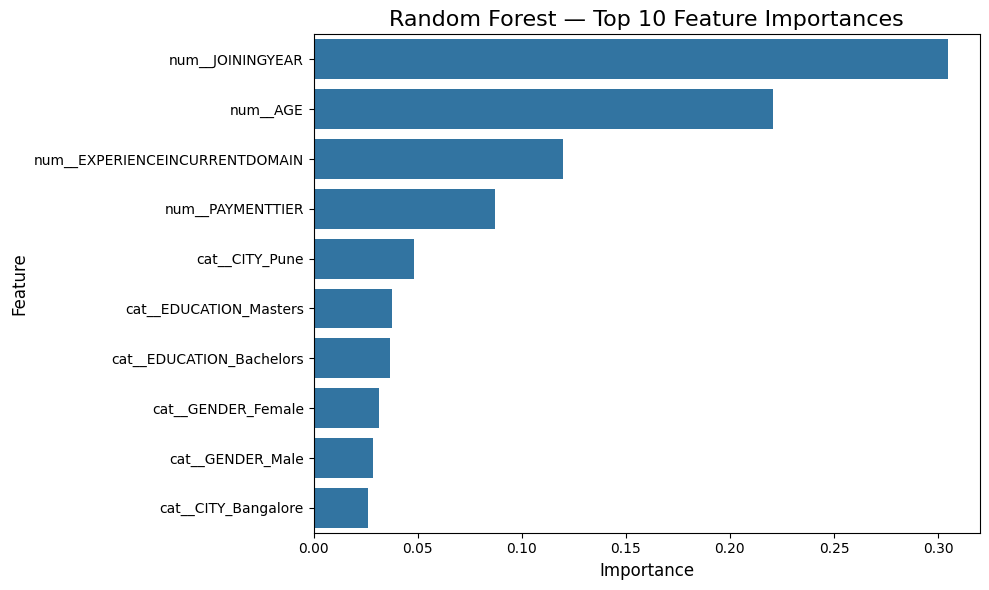

In [63]:
feature_names = preprocessor_stack[-1].get_feature_names_out()
importances   = pipeline.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df.head(10))
plt.title('Random Forest — Top 10 Feature Importances', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [64]:
# YOUR COMMENTS
# Age is the most important feature — younger employees are significantly more likely to leave.
# JoiningYear: recently joined employees are higher churn risk.
# ExperienceInCurrentDomain: low experience = higher churn probability.
# EverBenched=Yes: idle time strongly correlates with churn intent.
# PaymentTier: lower tier employees carry higher churn risk.
#
# OVERALL: Young employees, short tenure, low experience, ever benched, lower pay tier = HIGHEST CHURN RISK.
# Company should consider targeted retention programs for this segment.